In [1]:
import os
os.environ["HF_HOME"] = f"/scratch/{os.environ['USER']}/.cache/huggingface"
print(os.environ["HF_HOME"])  # confirm path looks right


/scratch/koppisetty.e/.cache/huggingface


In [2]:
import torch
print(torch.cuda.is_available())      # must be True
print(torch.cuda.get_device_name(0))  # should say A100

True
NVIDIA A100-SXM4-80GB


In [3]:
import torch
print(torch.cuda.is_available())

True


In [4]:
print(torch.__version__)

2.8.0+cu128


In [5]:
!pip install transformer_lens==1.6.0 -q

In [14]:
import torch
import random
import numpy as np

NAMES = [
    "Aaron", "Adam", "Alice", "Amy", "Andrew", "Anna", "Bob",
    "Brian", "Carol", "Charlie", "Chris", "Claire", "David",
    "Diana", "Edward", "Emily", "Emma", "Eric", "Frank", "George",
    "Grace", "Hannah", "Henry", "Jack", "James", "Jane", "Jason",
    "Jennifer", "John", "Julia", "Kate", "Kevin", "Laura", "Linda",
    "Lisa", "Luke", "Mark", "Mary", "Michael", "Nancy", "Oliver",
    "Paul", "Peter", "Rachel", "Robert", "Ryan", "Sarah", "Tom",
]
PLACES  = ["store", "park", "school", "office", "bank", "restaurant", "market"]
OBJECTS = ["drink", "gift", "book", "ball", "bag", "pen", "note"]


class IOIDataset:
    """
    Self-contained IOI dataset that does not depend on
    transformer_lens.ioi_dataset (removed in newer TL versions).
    Generates ABBA or ABAB prompts with single-token names.
    """

    def __init__(self, prompt_type: str, N: int, tokenizer, prepend_bos=True, seed=42):
        random.seed(seed)
        np.random.seed(seed)

        self.prompt_type = prompt_type
        self.tokenizer   = tokenizer
        self.prepend_bos = prepend_bos

        # Keep only names that tokenize to a single token (with leading space)
        self.valid_names = [
            n for n in NAMES
            if len(tokenizer.encode(" " + n)) == 1
        ]
        print(f"Valid single-token names: {len(self.valid_names)}")
        assert len(self.valid_names) >= 3, "Need at least 3 single-token names"

        self._build(N)

    # ------------------------------------------------------------------ #
    def _build(self, N: int):
        prompts      = []
        io_ids, s_ids = [], []
        io_pos_list, s1_pos_list, s2_pos_list, end_pos_list = [], [], [], []

        for _ in range(N):
            io_name, s_name, _ = random.sample(self.valid_names, 3)
            place  = random.choice(PLACES)
            obj    = random.choice(OBJECTS)

            if self.prompt_type == "ABBA":
                text = (f"When {io_name} and {s_name} went to the {place}, "
                        f"{s_name} gave a {obj} to")
            else:  # ABAB
                text = (f"When {s_name} and {io_name} went to the {place}, "
                        f"{s_name} gave a {obj} to")

            prompts.append(text)

            # Tokenize this single prompt to find name positions
            toks_list = self.tokenizer.encode(text)

            io_tok = self.tokenizer.encode(" " + io_name)[0]
            s_tok  = self.tokenizer.encode(" " + s_name)[0]

            io_ids.append(io_tok)
            s_ids.append(s_tok)

            io_pos = toks_list.index(io_tok)
            s_all  = [i for i, t in enumerate(toks_list) if t == s_tok]

            io_pos_list.append(io_pos)
            s1_pos_list.append(s_all[0])
            s2_pos_list.append(s_all[1])
            end_pos_list.append(len(toks_list) - 1)

        # Batch-tokenize with padding
        encoded = self.tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            add_special_tokens=self.prepend_bos,
        )

        self.toks        = encoded["input_ids"]          # [N, seq_len]
        self.io_tokenIDs = io_ids                        # list[int]
        self.s_tokenIDs  = s_ids                         # list[int]
        self.word_idx    = {
            "IO":  torch.tensor(io_pos_list),
            "S1":  torch.tensor(s1_pos_list),
            "S2":  torch.tensor(s2_pos_list),
            "end": torch.tensor(end_pos_list),
        }

    # ------------------------------------------------------------------ #
    def gen_flipped_prompts(self, flip: str) -> "IOIDataset":
        """
        Returns a new IOIDataset with fresh random names (ABC corruption).
        All three name slots get new, distinct names — the correct
        equivalent of the old TransformerLens ABC flip.
        """
        assert flip == "ABC", f"Only 'ABC' flip supported, got {flip!r}"
        flipped              = IOIDataset.__new__(IOIDataset)
        flipped.prompt_type  = self.prompt_type
        flipped.tokenizer    = self.tokenizer
        flipped.prepend_bos  = self.prepend_bos
        flipped.valid_names  = self.valid_names
        flipped._build(len(self.io_tokenIDs))
        return flipped

    def __len__(self) -> int:
        return len(self.io_tokenIDs)

In [15]:
ds = IOIDataset("ABBA", N=5, tokenizer=model.tokenizer, prepend_bos=True)
print(model.tokenizer.decode(ds.toks[0]))
print("IO pos:", ds.word_idx["IO"].tolist())
print("S2 pos:", ds.word_idx["S2"].tolist())
print("end pos:", ds.word_idx["end"].tolist())

Valid single-token names: 48
When Oliver and Brian went to the restaurant, Brian gave a book to
IO pos: [1, 1, 1, 1, 1]
S2 pos: [9, 9, 9, 9, 9]
end pos: [13, 13, 13, 13, 13]


In [16]:
DEVICE = "cuda"
model = model.to(DEVICE)

# Check logit difference on clean prompts
ds = IOIDataset("ABBA", N=50, tokenizer=model.tokenizer, prepend_bos=True)
clean_toks = ds.toks.to(DEVICE)

with torch.no_grad():
    logits = model(clean_toks)

end_pos = ds.word_idx["end"].to(DEVICE)
io_ids  = torch.tensor(ds.io_tokenIDs, device=DEVICE)
s_ids   = torch.tensor(ds.s_tokenIDs,  device=DEVICE)
batch_idx = torch.arange(len(ds), device=DEVICE)

final_logits = logits[batch_idx, end_pos]
io_logit = final_logits[batch_idx, io_ids]
s_logit  = final_logits[batch_idx, s_ids]
ld = (io_logit - s_logit).mean().item()
print(f"Clean logit difference: {ld:.3f}")

Moving model to device:  cuda
Valid single-token names: 48
Clean logit difference: 4.492


In [17]:
# Test STR corruption (S2 only)
abc = ds.gen_flipped_prompts("ABC")
corrupted_toks = ds.toks.clone().to(DEVICE)
abc_toks = abc.toks.to(DEVICE)

for i in range(len(ds)):
    s2_pos = ds.word_idx["S2"][i].item()
    corrupted_toks[i, s2_pos] = abc_toks[i, s2_pos]

with torch.no_grad():
    corrupted_logits = model(corrupted_toks)

final_corrupted = corrupted_logits[batch_idx, end_pos]
io_logit_c = final_corrupted[batch_idx, io_ids]
s_logit_c  = final_corrupted[batch_idx, s_ids]
ld_corrupted = (io_logit_c - s_logit_c).mean().item()

print(f"Clean logit difference:     {ld:.3f}")
print(f"Corrupted logit difference: {ld_corrupted:.3f}")
print(f"Delta:                      {ld - ld_corrupted:.3f}")

Clean logit difference:     4.492
Corrupted logit difference: 0.070
Delta:                      4.422


In [ ]:
#!/usr/bin/env python3
"""
Patching Under Pressure: Stress-Testing Causal Interpretability
Across Experimental Choices
CS7180 | Easha Meher Koppisetty

Run on Colab (GPU runtime) or Northeastern Discovery cluster.

Setup:
    pip install transformer_lens einops pandas matplotlib seaborn tqdm

Colab tip: Runtime → Change runtime type → T4 GPU
HPC tip:   Request 1 GPU node, ~16GB VRAM, ~4hr walltime is plenty
"""

# ═══════════════════════════════════════════════════════════════════════════
# §0  IMPORTS & GLOBAL CONFIG
# ═══════════════════════════════════════════════════════════════════════════
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from functools import partial
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

from transformer_lens import HookedTransformer


# ── Reproducibility ───────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# ── Experiment scale (reduce N_PROMPTS to 200 if you hit GPU OOM) ─────────
N_PROMPTS   = 500
DETECT_NSTD = 2.0   # Zhang & Nanda's threshold: mean + 2σ
GN_STD_MULT = 3.0   # noise std = GN_STD_MULT × embedding std (Zhang & Nanda)


# ═══════════════════════════════════════════════════════════════════════════
# §1  MODEL LOADING
# ═══════════════════════════════════════════════════════════════════════════
print("Loading Pythia-1.4B via TransformerLens …")
model = HookedTransformer.from_pretrained(
    "EleutherAI/pythia-1.4b",
    center_unembed=True,
    center_writing_weights=True,
    fold_ln=True,
    device=DEVICE,
)
model.eval()

N_LAYERS = model.cfg.n_layers   # 24
N_HEADS  = model.cfg.n_heads    # 16
D_MODEL  = model.cfg.d_model    # 2048
print(f"Architecture: {N_LAYERS} layers × {N_HEADS} heads × d_model={D_MODEL}")


# ═══════════════════════════════════════════════════════════════════════════
# §2  KNOWN IOI CIRCUIT COMPONENTS
#
#  ⚠  UPDATE THESE before final results!
#  Source: Hanna et al. (2024) "LLM Circuit Analyses Are Consistent Across
#          Training and Scale" — check their Table 2 / appendix for Pythia-1.4B
#          exact (layer, head) indices and replace the placeholders below.
#
#  The detection scoring depends entirely on this dict being correct.
#  For your reproduction baseline (Condition 1), verify that the known heads
#  ARE detected under standard settings before trusting other conditions.
# ═══════════════════════════════════════════════════════════════════════════
KNOWN_CIRCUIT = {
    "Name Mover":      [(22, 2), (21, 3), (17, 0)],
    "S-Inhibition":    [(10, 7), (15, 15), (11, 8)],
    "Duplicate Token": [(4, 5),  (4, 7)],
    "Induction":       [(7, 15), (7, 6)],
}

COMP_COLORS = {
    "Name Mover":      "yellow",
    "S-Inhibition":    "lime",
    "Duplicate Token": "cyan",
    "Induction":       "orange",
}


# ═══════════════════════════════════════════════════════════════════════════
# §3  IOI DATASET UTILITIES
# ═══════════════════════════════════════════════════════════════════════════

# Cache datasets so that conditions sharing the same template use identical prompts
_dataset_cache: dict[str, IOIDataset] = {}

def get_dataset(prompt_type: str, N: int = N_PROMPTS) -> IOIDataset:
    """Returns (and caches) an IOIDataset for the given template."""
    key = f"{prompt_type}_{N}"
    if key not in _dataset_cache:
        _dataset_cache[key] = IOIDataset(
            prompt_type=prompt_type,
            N=N,
            tokenizer=model.tokenizer,
            prepend_bos=True,
        )
    return _dataset_cache[key]


def make_str_corrupted_tokens(
    dataset: IOIDataset,
    corrupt_target: str,          # 'S2' | 'S1+IO'
) -> torch.Tensor:
    """
    Subject Token Replacement (STR) corruption.

    'S2':    replace only the S2 token with a new name (subject no longer repeated)
    'S1+IO': replace S1 and IO tokens with new names (S2 becomes the "odd one out")

    New name tokens are drawn from the ABC-flipped dataset (all-distinct names),
    ensuring every replacement is a valid single-token name.

    Returns shape [N, seq_len] on DEVICE.
    """
    abc      = dataset.gen_flipped_prompts("ABC")
    corrupt  = dataset.toks.clone().to(DEVICE)
    abc_toks = abc.toks.to(DEVICE)

    for i in range(len(dataset)):
        if corrupt_target == "S2":
            pos = dataset.word_idx["S2"][i].item()
            corrupt[i, pos] = abc_toks[i, pos]

        elif corrupt_target == "S1+IO":
            s1_pos = dataset.word_idx["S1"][i].item()
            io_pos = dataset.word_idx["IO"][i].item()
            corrupt[i, s1_pos] = abc_toks[i, s1_pos]
            corrupt[i, io_pos] = abc_toks[i, io_pos]

        else:
            raise ValueError(f"Unknown corrupt_target: {corrupt_target!r}")

    return corrupt


# ═══════════════════════════════════════════════════════════════════════════
# §4  METRIC — MEAN LOGIT DIFFERENCE
# ═══════════════════════════════════════════════════════════════════════════

def mean_logit_diff(logits: torch.Tensor, dataset: IOIDataset) -> float:
    """
    Mean (IO_logit − S_logit) at each prompt's final query position.
    Higher → model more strongly prefers the correct IO over the subject name.
    Token IDs always come from the CLEAN dataset regardless of corruption.
    """
    end_pos = dataset.word_idx["end"].to(DEVICE)           # [N]
    io_ids  = torch.tensor(dataset.io_tokenIDs, device=DEVICE)  # [N]
    s_ids   = torch.tensor(dataset.s_tokenIDs,  device=DEVICE)  # [N]

    batch_idx    = torch.arange(logits.shape[0], device=DEVICE)
    final_logits = logits[batch_idx, end_pos]               # [N, vocab]

    io_logit = final_logits[batch_idx, io_ids]
    s_logit  = final_logits[batch_idx, s_ids]
    return (io_logit - s_logit).mean().item()


# ═══════════════════════════════════════════════════════════════════════════
# §5  CACHING HELPERS
# ═══════════════════════════════════════════════════════════════════════════

def get_hook_z_cache(tokens, extra_hooks=None):
    if extra_hooks:
        for name, fn in extra_hooks:
            model.add_hook(name, fn)

    logits, cache = model.run_with_cache(
        tokens,
        return_type="logits",
        names_filter=lambda n: n.endswith("hook_z"),
    )

    if extra_hooks:
        model.reset_hooks()

    return logits, cache


# ═══════════════════════════════════════════════════════════════════════════
# §6  ACTIVATION PATCHING ENGINE
# ═══════════════════════════════════════════════════════════════════════════

def _replace_head_hook(
    act: torch.Tensor,          # [batch, seq, n_heads, d_head]
    hook,
    head_idx: int,
    source: torch.Tensor,       # same shape as act
) -> torch.Tensor:
    act[:, :, head_idx, :] = source[:, :, head_idx, :]
    return act


def compute_patching_effects(
    run_tokens: torch.Tensor,       # tokens to run the model on
    source_cache: dict,             # activations to patch IN at each head
    metric_fn,                      # callable(logits) → float
    baseline_metric: float,         # metric on unpatched run_tokens
    target_metric: float,           # metric we are trying to move toward
    noise_hook=None,                # optional (name, fn) for GN injection
) -> torch.Tensor:
    """
    For every (layer, head), patches that head's hook_z from source_cache
    into a forward pass on run_tokens and records the normalized effect.

    Denoising:
        run_tokens = corrupted, source_cache = clean
        baseline = corrupted metric (~low), target = clean metric (~high)
        effect → 1 means full recovery; head is SUFFICIENT for behavior

    Noising:
        run_tokens = clean, source_cache = corrupted
        baseline = clean metric (~high), target = corrupted metric (~low)
        effect → 1 means full degradation; head is NECESSARY for behavior

    Both directions: effect ≈ 1 for important heads, ≈ 0 for unimportant.
    """
    denom = target_metric - baseline_metric
    if abs(denom) < 1e-8:
        print("  ⚠  baseline ≈ target — check prompts/corruption")
        return torch.zeros(N_LAYERS, N_HEADS)

    effects = torch.zeros(N_LAYERS, N_HEADS)

    for layer in tqdm(range(N_LAYERS), desc="  layers", leave=False):
        hook_name = f"blocks.{layer}.attn.hook_z"
        src       = source_cache[hook_name].to(DEVICE)      # [N, seq, heads, d_head]

        for head in range(N_HEADS):
            patch_fn = partial(_replace_head_hook, head_idx=head, source=src)
            hooks    = [(hook_name, patch_fn)]
            if noise_hook is not None:
                hooks = [noise_hook] + hooks

            with torch.no_grad():
                patched_logits = model.run_with_hooks(
                    run_tokens,
                    fwd_hooks=hooks,
                    return_type="logits",
                )

            pm = metric_fn(patched_logits)
            effects[layer, head] = (pm - baseline_metric) / denom

    return effects


def run_condition(
    dataset: IOIDataset,
    direction: str,           # 'denoising' | 'noising'
    corrupt_target: str,      # 'S2' | 'S1+IO'
    corruption_method: str,   # 'STR' | 'GN'
) -> torch.Tensor:
    """
    Runs one full experimental condition and returns an [N_LAYERS, N_HEADS]
    normalized patching effects tensor.
    """
    clean_toks = dataset.toks.to(DEVICE)
    metric_fn  = partial(mean_logit_diff, dataset=dataset)
    noise_hook = None

    # ── Build corrupted representation ────────────────────────────────────
    if corruption_method == "STR":
        corrupted_toks = make_str_corrupted_tokens(dataset, corrupt_target)

        with torch.no_grad():
            clean_logits,     clean_cache     = get_hook_z_cache(clean_toks)
            corrupted_logits, corrupted_cache = get_hook_z_cache(corrupted_toks)

        clean_metric     = metric_fn(clean_logits)
        corrupted_metric = metric_fn(corrupted_logits)

    elif corruption_method == "GN":
        # Compute noise std from the data's own embedding distribution
        with torch.no_grad():
            _, embed_cache = model.run_with_cache(
                clean_toks,
                return_type=None,
                names_filter=lambda n: n == "hook_embed",
            )
            embed_std = embed_cache["hook_embed"].std().item()
        gn_std = GN_STD_MULT * embed_std

        # Fixed noise tensor — same for every forward pass in this condition
        seq_len    = clean_toks.shape[1]
        fixed_noise = torch.randn(len(dataset), seq_len, D_MODEL, device=DEVICE) * gn_std

        def _noise_fn(resid, hook):
            return resid + fixed_noise

        noise_hook = ("blocks.0.hook_resid_pre", _noise_fn)

        with torch.no_grad():
            clean_logits, clean_cache = get_hook_z_cache(clean_toks)
            corrupted_logits, corrupted_cache = get_hook_z_cache(
                clean_toks, extra_hooks=[noise_hook]
            )

        clean_metric     = metric_fn(clean_logits)
        corrupted_metric = metric_fn(corrupted_logits)
        # For GN, 'corrupted_toks' is still clean_toks — noise is injected via hook
        corrupted_toks = clean_toks

    else:
        raise ValueError(f"Unknown corruption_method: {corruption_method!r}")

    print(
        f"  clean LD={clean_metric:.3f}  "
        f"corrupted LD={corrupted_metric:.3f}  "
        f"Δ={clean_metric - corrupted_metric:.3f}"
    )

    # ── Dispatch to patching engine ────────────────────────────────────────
    if direction == "denoising":
        return compute_patching_effects(
            run_tokens      = corrupted_toks,
            source_cache    = clean_cache,
            metric_fn       = metric_fn,
            baseline_metric = corrupted_metric,
            target_metric   = clean_metric,
            noise_hook      = noise_hook if corruption_method == "GN" else None,
        )

    elif direction == "noising":
        # For noising with GN: patch GN-corrupted activations into clean run.
        # noise_hook is NOT injected here; we're running clean tokens cleanly.
        return compute_patching_effects(
            run_tokens      = clean_toks,
            source_cache    = corrupted_cache,
            metric_fn       = metric_fn,
            baseline_metric = clean_metric,
            target_metric   = corrupted_metric,
            noise_hook      = None,
        )

    else:
        raise ValueError(f"Unknown direction: {direction!r}")


# ═══════════════════════════════════════════════════════════════════════════
# §7  DETECTION & COMPARISON
#
#  Prof. Wallace's question: "meaning exact module/head match, or something
#  more relaxed?"
#
#  We implement THREE levels of comparison, so results can be reported at
#  whichever grain the reader cares about:
#
#  (a) Strict:   exact (layer, head) set equality
#  (b) Relaxed:  component-type detection score  "n_detected / total"
#  (c) Graded:   Jaccard similarity between detected head sets
#
#  Prof. Wallace's other question: "this itself seems like a pretty important
#  assumption/hyperparameter" (on the 2-SD threshold).
#  → run_threshold_sensitivity() sweeps multiple thresholds so we can report
#    whether any conclusion changes if we use 1.5 or 2.5 SD instead.
# ═══════════════════════════════════════════════════════════════════════════

def detect_heads(effects: torch.Tensor, n_std: float = DETECT_NSTD) -> set:
    """
    (a/b/c) Returns set of (layer, head) tuples whose effect exceeds
    mean + n_std × std — Zhang & Nanda's criterion exactly.
    """
    flat      = effects.flatten()
    threshold = flat.mean() + n_std * flat.std()
    return {
        (l, h)
        for l in range(N_LAYERS)
        for h in range(N_HEADS)
        if effects[l, h].item() >= threshold.item()
    }


def score_detection(detected: set) -> dict:
    """
    (b) Relaxed: for each known component type, 'n_detected / total'.
    Also reports total detected heads (for false-positive context).
    """
    scores = {
        comp: f"{sum(1 for h in heads if h in detected)}/{len(heads)}"
        for comp, heads in KNOWN_CIRCUIT.items()
    }
    scores["Total Detected"] = len(detected)
    return scores


def jaccard(set_a: set, set_b: set) -> float:
    """(c) Graded: Jaccard similarity between two detected head sets."""
    if not set_a and not set_b:
        return 1.0
    return len(set_a & set_b) / len(set_a | set_b)


def circuit_changed_strict(set_a: set, set_b: set) -> bool:
    """(a) Strict: True if the two detected head sets are not identical."""
    return set_a != set_b


def run_threshold_sensitivity(
    effects_by_cid: dict,
    thresholds=(1.5, 2.0, 2.5, 3.0),
) -> pd.DataFrame:
    """
    Sweeps the detection threshold and reports how detected head counts
    change. Addresses Prof. Wallace's concern that 2-SD is an important
    hyperparameter. If conclusions are stable across thresholds → robust.
    """
    rows = []
    for n_std in thresholds:
        for cid, effects in effects_by_cid.items():
            detected = detect_heads(effects, n_std=n_std)
            scores   = score_detection(detected)
            rows.append({
                "Cond": cid,
                "Threshold (nSD)": n_std,
                **scores,
            })
    return pd.DataFrame(rows)


# ═══════════════════════════════════════════════════════════════════════════
# §8  MAIN EXPERIMENT LOOP
# ═══════════════════════════════════════════════════════════════════════════
#
#  The 8 main conditions cross direction × template × token_corrupted (all STR).
#  Condition 9 is the Zhang & Nanda replication ablation (GN vs STR).
#
CONDITIONS = [
    (1, 'denoising', 'ABBA', 'S2',    'STR'),
    (2, 'denoising', 'ABBA', 'S1+IO', 'STR'),
    (3, 'denoising', 'ABAB', 'S2',    'STR'),
    (4, 'denoising', 'ABAB', 'S1+IO', 'STR'),
    (5, 'noising',   'ABBA', 'S2',    'STR'),
    (6, 'noising',   'ABBA', 'S1+IO', 'STR'),
    (7, 'noising',   'ABAB', 'S2',    'STR'),
    (8, 'noising',   'ABAB', 'S1+IO', 'STR'),
    (9, 'denoising', 'ABBA', 'S2',    'GN'),
]
results_rows:   list[dict]              = []
effects_by_cid: dict[int, torch.Tensor] = {}
detected_by_cid: dict[int, set]         = {}

for (cid, direction, template, tok_corrupt, corr_method) in CONDITIONS:
    label = f"C{cid}: {direction[:5]} | {template} | {tok_corrupt} | {corr_method}"
    print(f"\n{'─'*64}")
    print(f"  {label}")

    dataset = get_dataset(template)

    effects = run_condition(
        dataset          = dataset,
        direction        = direction,
        corrupt_target   = tok_corrupt,
        corruption_method= corr_method,
    )

    detected = detect_heads(effects)
    scores   = score_detection(detected)

    results_rows.append({
        "Cond":            cid,
        "Direction":       direction,
        "Template":        template,
        "Token Corrupted": tok_corrupt,
        "Corruption":      corr_method,
        **scores,
    })
    effects_by_cid[cid] = effects

    comp_summary = "  │  ".join(
        f"{k}: {v}" for k, v in scores.items() if k != "Total Detected"
    )
    print(f"  Detected {scores['Total Detected']} heads  │  {comp_summary}")
    # Store detected sets for Jaccard / strict comparison
    detected_by_cid[cid] = detected


# ═══════════════════════════════════════════════════════════════════════════
# §9  RESULTS TABLE
# ═══════════════════════════════════════════════════════════════════════════
df = pd.DataFrame(results_rows)

print("\n\n" + "═" * 72)
print("DETECTION TABLE — PATCHING UNDER PRESSURE")
print("═" * 72)
print(df.to_string(index=False))

df.to_csv("detection_results.csv", index=False)
print("\nSaved → detection_results.csv")


# ═══════════════════════════════════════════════════════════════════════════
# §10  VISUALIZATION — HEATMAPS
# ═══════════════════════════════════════════════════════════════════════════

def plot_heatmap(effects: torch.Tensor, title: str, ax=None) -> None:
    """
    Heatmap of [N_LAYERS × N_HEADS] normalized patching effects.
    Colored boxes mark known IOI circuit heads (see legend).
    """
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(12, 8))

    data = effects.detach().cpu().float().numpy()
    sns.heatmap(
        data, ax=ax,
        cmap="RdBu_r", center=0,
        vmin=-0.3, vmax=1.0,
        xticklabels=range(N_HEADS),
        yticklabels=range(N_LAYERS),
        linewidths=0,
        cbar_kws={"label": "Normalized Effect", "shrink": 0.55},
    )
    ax.set_xlabel("Head", fontsize=9)
    ax.set_ylabel("Layer", fontsize=9)
    ax.set_title(title, fontsize=10, pad=3)
    ax.tick_params(labelsize=7)

    for comp, heads in KNOWN_CIRCUIT.items():
        color = COMP_COLORS[comp]
        for (l, h) in heads:
            if l < N_LAYERS and h < N_HEADS:
                ax.add_patch(
                    plt.Rectangle((h, l), 1, 1, fill=False,
                                  edgecolor=color, lw=2.0)
                )

    if standalone:
        legend_patches = [
            mpatches.Patch(edgecolor=c, facecolor="none", lw=2, label=k)
            for k, c in COMP_COLORS.items()
        ]
        ax.legend(handles=legend_patches, loc="upper right",
                  fontsize=7, framealpha=0.7)
        plt.tight_layout()
        plt.show()


# 2 × 4 grid of all 8 STR conditions
fig, axes = plt.subplots(2, 4, figsize=(28, 14))
for i, (cid, dir_, tmpl, tok, _corr) in enumerate(CONDITIONS[:8]):
    title = f"C{cid}: {dir_[:5]} | {tmpl} | {tok}"
    plot_heatmap(effects_by_cid[cid], title, ax=axes.flatten()[i])

legend_patches = [
    mpatches.Patch(edgecolor=c, facecolor="none", lw=2, label=k)
    for k, c in COMP_COLORS.items()
]
fig.legend(handles=legend_patches, loc="lower center", ncol=4,
           fontsize=10, framealpha=0.8, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Patching Under Pressure — All 8 STR Conditions",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("heatmaps_all_conditions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → heatmaps_all_conditions.png")

# STR vs GN comparison (replication check)
if 9 in effects_by_cid:
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    plot_heatmap(effects_by_cid[1], "C1 (STR): Denoising | ABBA | S2  — baseline",   ax=axes[0])
    plot_heatmap(effects_by_cid[9], "C9 (GN):  Denoising | ABBA | S2  — replication", ax=axes[1])
    fig.suptitle("Replication Check: STR vs GN Corruption\n"
                 "(reproduces Zhang & Nanda 2023 finding on Pythia-1.4B)", fontsize=12)
    plt.tight_layout()
    plt.savefig("replication_str_vs_gn.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved → replication_str_vs_gn.png")


# ═══════════════════════════════════════════════════════════════════════════
# §11  AXIS-BY-AXIS SENSITIVITY SUMMARY
# ═══════════════════════════════════════════════════════════════════════════
comp_cols = list(KNOWN_CIRCUIT.keys())

def print_axis_summary(
    df: pd.DataFrame,
    axis_col: str,
    axis_vals: list,
    filter_col: str = None,
    filter_val = None,
) -> None:
    sub = df if filter_col is None else df[df[filter_col] == filter_val]
    header = f"Axis: {axis_col}"
    if filter_col:
        header += f"  ({filter_col}={filter_val})"
    print(f"\n── {header} ──")
    for col in comp_cols:
        row_results = {
            v: sub[sub[axis_col] == v][col].tolist()
            for v in axis_vals
        }
        all_vals   = [x for xs in row_results.values() for x in xs]
        consistent = len(set(all_vals)) == 1
        status     = "✓ consistent" if consistent else "✗ VARIES"
        detail     = "  |  ".join(f"{k} → {v}" for k, v in row_results.items())
        print(f"  {col:<20}: {detail}   [{status}]")


print("\n\n" + "═" * 72)
print("AXIS-BY-AXIS SENSITIVITY ANALYSIS (STR conditions only)")
print("═" * 72)
df_str = df[df["Corruption"] == "STR"]

print_axis_summary(df_str, "Direction",       ["denoising", "noising"])
print_axis_summary(df_str, "Template",        ["ABBA",     "ABAB"])
print_axis_summary(df_str, "Token Corrupted", ["S2",       "S1+IO"])

# Replication: C1 (STR) vs C9 (GN)
if 9 in effects_by_cid:
    print("\n── Replication: STR vs GN  (held constant: denoising | ABBA | S2) ──")
    c1 = df[df["Cond"] == 1].iloc[0]
    c9 = df[df["Cond"] == 9].iloc[0]
    for col in comp_cols:
        status = "✓ same" if c1[col] == c9[col] else "✗ DIFFERENT"
        print(f"  {col:<20}: STR={c1[col]}  GN={c9[col]}   [{status}]")


# ── (c) Jaccard similarity matrix across the 8 main STR conditions ───────
# Addresses Prof. Wallace: "exact match or something more relaxed?"
# Values near 1.0 = same heads detected; near 0.0 = completely different sets.
print("\n── Jaccard Similarity (detected head sets, STR conditions) ──")
cids_str = [c[0] for c in CONDITIONS[:8]]
jac_matrix = pd.DataFrame(index=cids_str, columns=cids_str, dtype=float)
for ci in cids_str:
    for cj in cids_str:
        jac_matrix.loc[ci, cj] = round(jaccard(detected_by_cid[ci], detected_by_cid[cj]), 2)
print(jac_matrix.to_string())
jac_matrix.to_csv("jaccard_similarity.csv")
print("Saved → jaccard_similarity.csv")

# ── Threshold sensitivity ─────────────────────────────────────────────────
# Addresses Prof. Wallace: "this itself seems like a pretty important
# assumption/hyperparameter"
print("\n── Threshold Sensitivity (do conclusions change at 1.5 / 2.5 / 3.0 SD?) ──")
df_thresh = run_threshold_sensitivity(effects_by_cid)
# Show just the component-type columns for conditions 1 and 5 (direction axis)
for cid in [1, 5]:
    sub = df_thresh[df_thresh["Cond"] == cid][["Threshold (nSD)"] + comp_cols]
    print(f"\n  Condition {cid}:")
    print(sub.to_string(index=False))
df_thresh.to_csv("threshold_sensitivity.csv", index=False)
print("Saved → threshold_sensitivity.csv")

# ── Actionable recommendations printout ──────────────────────────────────
print("\n\n" + "═" * 72)
print("RECOMMENDATIONS SUMMARY")
print("═" * 72)
print("(Fill these in after inspecting the detection tables above.)\n")
print("Direction   (denoising vs noising):   [consistent / VARIES]")
print("Template    (ABBA vs ABAB):           [consistent / VARIES]")
print("Token Corrupted (S2 vs S1+IO):        [consistent / VARIES]")
print("Corruption  (STR vs GN):              [consistent / VARIES]")
print()
print("Concrete advice for future researchers:")
print("  ▸ Choices that matter   (always specify): ?")
print("  ▸ Choices that don't    (free to pick):   ?")


# ═══════════════════════════════════════════════════════════════════════════
# §12  SAVE ALL EFFECTS (for later analysis / visualization)
# ═══════════════════════════════════════════════════════════════════════════
torch.save(effects_by_cid, "effects_all_conditions.pt")
df.to_csv("detection_results.csv", index=False)
print("\nSaved → effects_all_conditions.pt")
print("Done ✓")

Device: cuda
Loading Pythia-1.4B via TransformerLens …
Loaded pretrained model EleutherAI/pythia-1.4b into HookedTransformer
Architecture: 24 layers × 16 heads × d_model=2048

────────────────────────────────────────────────────────────────
  C1: denoi | ABBA | S2 | STR
Valid single-token names: 48
  clean LD=4.461  corrupted LD=0.031  Δ=4.430


  Detected 4 heads  │  Name Mover: 1/3  │  S-Inhibition: 3/3  │  Duplicate Token: 0/2  │  Induction: 0/2

────────────────────────────────────────────────────────────────
  C2: denoi | ABBA | S1+IO | STR
  clean LD=4.461  corrupted LD=-1.741  Δ=6.201


  Detected 13 heads  │  Name Mover: 2/3  │  S-Inhibition: 2/3  │  Duplicate Token: 0/2  │  Induction: 1/2

────────────────────────────────────────────────────────────────
  C3: denoi | ABAB | S2 | STR
Valid single-token names: 48
  clean LD=4.252  corrupted LD=-0.257  Δ=4.509


  Detected 5 heads  │  Name Mover: 1/3  │  S-Inhibition: 2/3  │  Duplicate Token: 0/2  │  Induction: 0/2

────────────────────────────────────────────────────────────────
  C4: denoi | ABAB | S1+IO | STR
  clean LD=4.252  corrupted LD=-1.733  Δ=5.985


  Detected 13 heads  │  Name Mover: 2/3  │  S-Inhibition: 2/3  │  Duplicate Token: 0/2  │  Induction: 1/2

────────────────────────────────────────────────────────────────
  C5: noisi | ABBA | S2 | STR
  clean LD=4.461  corrupted LD=0.123  Δ=4.338


  Detected 9 heads  │  Name Mover: 1/3  │  S-Inhibition: 3/3  │  Duplicate Token: 1/2  │  Induction: 1/2

────────────────────────────────────────────────────────────────
  C6: noisi | ABBA | S1+IO | STR
  clean LD=4.461  corrupted LD=-1.742  Δ=6.203


  Detected 11 heads  │  Name Mover: 2/3  │  S-Inhibition: 3/3  │  Duplicate Token: 1/2  │  Induction: 1/2

────────────────────────────────────────────────────────────────
  C7: noisi | ABAB | S2 | STR
  clean LD=4.252  corrupted LD=-0.171  Δ=4.423


  layers:  25%|██▌       | 6/24 [01:58<05:56, 19.82s/it]

In [22]:
effects = effects_by_cid[1]
flat = effects.flatten()
top_vals, top_idx = flat.topk(30)

print("Top 30 heads by patching effect (Layer, Head, Effect):")
for val, idx in zip(top_vals, top_idx):
    layer = idx.item() // N_HEADS
    head  = idx.item() %  N_HEADS
    print(f"  Layer {layer:2d}, Head {head:2d}  →  {val:.4f}")

Top 30 heads by patching effect (Layer, Head, Effect):
  Layer 10, Head  7  →  0.6859
  Layer 11, Head  8  →  0.1143
  Layer 15, Head 15  →  0.0908
  Layer 22, Head  2  →  0.0887
  Layer  9, Head  1  →  0.0735
  Layer 21, Head  3  →  0.0616
  Layer 12, Head 15  →  0.0360
  Layer 13, Head  6  →  0.0346
  Layer 17, Head  0  →  0.0340
  Layer 14, Head  6  →  0.0307
  Layer  7, Head 15  →  0.0297
  Layer 17, Head  7  →  0.0289
  Layer 22, Head 10  →  0.0254
  Layer 15, Head 11  →  0.0236
  Layer 11, Head 15  →  0.0211
  Layer  7, Head  6  →  0.0188
  Layer 15, Head  3  →  0.0181
  Layer 14, Head  8  →  0.0169
  Layer  4, Head  5  →  0.0164
  Layer 16, Head 13  →  0.0157
  Layer 10, Head 14  →  0.0156
  Layer 15, Head  9  →  0.0153
  Layer  4, Head  7  →  0.0147
  Layer 15, Head  1  →  0.0139
  Layer 17, Head 13  →  0.0131
  Layer 12, Head  8  →  0.0124
  Layer 11, Head 14  →  0.0123
  Layer  9, Head  9  →  0.0115
  Layer 23, Head  9  →  0.0109
  Layer 10, Head  5  →  0.0102


In [27]:
KNOWN_CIRCUIT = {
    "Name Mover":      [(22, 2), (21, 3), (17, 0)],
    "S-Inhibition":    [(10, 7), (15, 15), (11, 8)],
    "Duplicate Token": [(4, 5),  (4, 7)],
    "Induction":       [(7, 15), (7, 6)],
}

In [28]:
detected = detect_heads(effects_by_cid[1])
scores   = score_detection(detected)
print(scores)
print("Detected heads:", detected)

{'Name Mover': '1/3', 'S-Inhibition': '3/3', 'Duplicate Token': '0/2', 'Induction': '0/2', 'Total Detected': 4}
Detected heads: {(22, 2), (11, 8), (10, 7), (15, 15)}


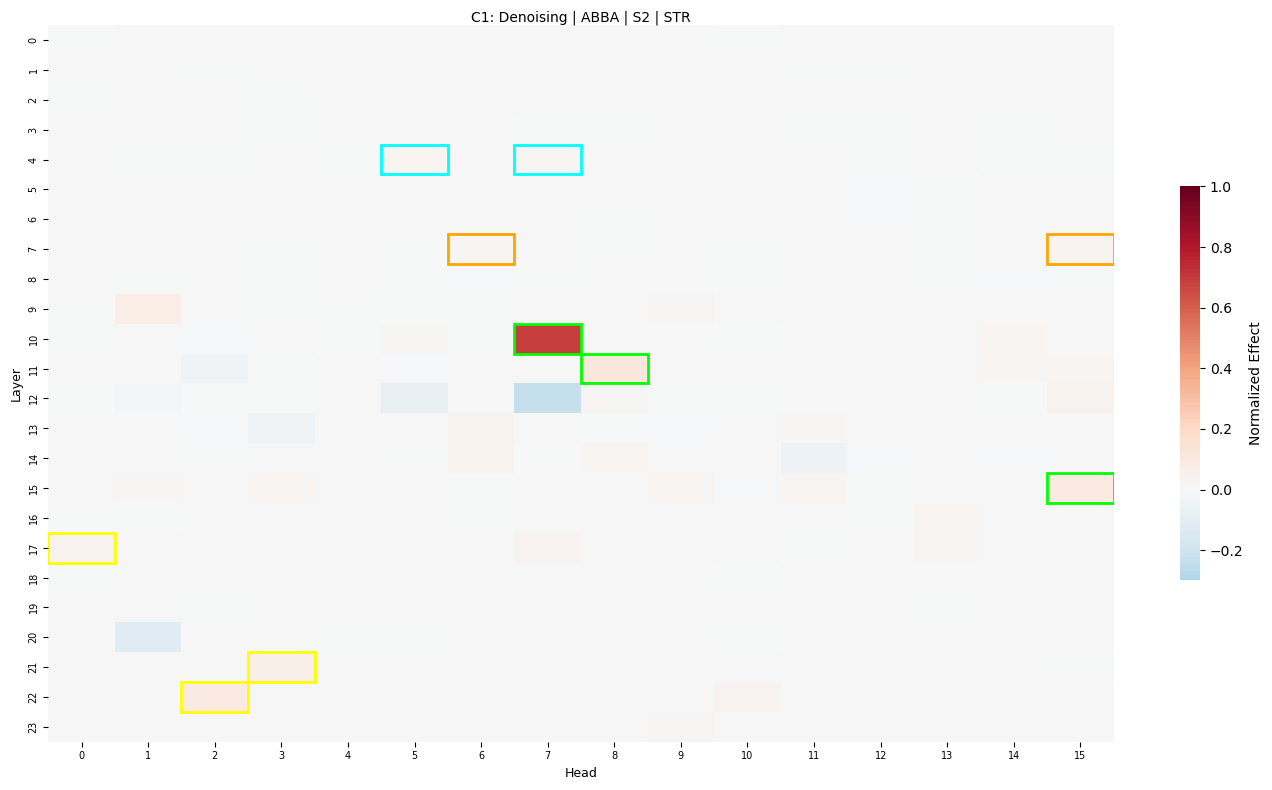

In [29]:
fig, ax = plt.subplots(figsize=(14, 8))
plot_heatmap(effects_by_cid[1], "C1: Denoising | ABBA | S2 | STR", ax=ax)
plt.tight_layout()
plt.savefig("c1_reproduction_baseline.png", dpi=150)
plt.show()

In [26]:
# Look at what's in early layers specifically
print("Early layer heads (layers 0-8):")
for l in range(9):
    for h in range(N_HEADS):
        val = effects_by_cid[1][l, h].item()
        if val > 0.01:
            print(f"  Layer {l:2d}, Head {h:2d}  →  {val:.4f}")

Early layer heads (layers 0-8):
  Layer  4, Head  5  →  0.0164
  Layer  4, Head  7  →  0.0147
  Layer  7, Head  6  →  0.0188
  Layer  7, Head 15  →  0.0297
